In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import sqlite3

In [3]:
data = '/Users/williamkeck/Desktop/coolstuff/CLOUD_gammas_fill_FP_parallel_16mm_13.db'

In [13]:
def inspect_db_file(db_file):
    try:
        # Connect to the SQLite database
        conn = sqlite3.connect(db_file)
        cursor = conn.cursor()

        # Get the list of tables in the database
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()

        print("Tables in the database:")
        for table in tables:
            print(table[0])

            # Get the structure of each table
            cursor.execute(f"PRAGMA table_info({table[0]})")
            columns = cursor.fetchall()
            print("Columns:")
            for column in columns:
                print(column)

    except sqlite3.Error as e:
        print(f"An error occurred: {e}")
    finally:
        if conn:
            conn.close()
inspect_db_file(data)

Tables in the database:
DAQData
Columns:
(0, 'sipmID', 'FLOAT', 0, None, 0)
(1, 'sipm_x', 'FLOAT', 0, None, 0)
(2, 'sipm_y', 'FLOAT', 0, None, 0)
(3, 'sipm_z', 'FLOAT', 0, None, 0)
(4, 'time', 'FLOAT', 0, None, 0)
(5, 'charge', 'FLOAT', 0, None, 0)
(6, 'event_no', '', 1, None, 0)
TruthData
Columns:
(0, 'vertex_x', 'FLOAT', 0, None, 0)
(1, 'vertex_y', 'FLOAT', 0, None, 0)
(2, 'vertex_z', 'FLOAT', 0, None, 0)
(3, 'zenith', 'FLOAT', 0, None, 0)
(4, 'azimuth', 'FLOAT', 0, None, 0)
(5, 'interaction_time', 'FLOAT', 0, None, 0)
(6, 'energy', 'FLOAT', 0, None, 0)
(7, 'pid', 'FLOAT', 0, None, 0)
(8, 'event_no', 'INTEGER', 1, None, 1)


In [16]:
#return 1 row of data from the table
def get_data_from_table(db_file, table_name):
    try:
        conn = sqlite3.connect(db_file)
        cursor = conn.cursor()
        
        # Fetch one row of data from the specified table
        cursor.execute(f"SELECT * FROM {table_name} LIMIT 1")
        row = cursor.fetchone()
        
        return row

    except sqlite3.Error as e:
        print(f"An error occurred: {e}")
    finally:
        if conn:
            conn.close()
DAQ = get_data_from_table(data, 'DAQData')
Truth = get_data_from_table(data, 'TruthData')


In [27]:
#print all lines in the DAQ table with the same event_no
def get_all_rows_with_event_no(db_file, table_name, event_no):
    try:
        conn = sqlite3.connect(db_file)
        cursor = conn.cursor()
        
        # Fetch all rows with the specified event_no
        cursor.execute(f"SELECT * FROM {table_name} WHERE event_no = ?", (event_no,))
        rows = cursor.fetchall()
        
        return rows

    except sqlite3.Error as e:
        print(f"An error occurred: {e}")
    finally:
        if conn:
            conn.close()
DAQ_1 = DAQ_rows = get_all_rows_with_event_no(data, 'DAQData', 0)
print(DAQ_rows)

[(9918.0, -32.0, 554.2562866210938, 2000.0, 32.23220443725586, 3.9716429710388184, 0), (10009.0, 8.0, 568.1126708984375, 2000.0, 28.303627014160156, 8.21368408203125, 0), (10010.0, 24.0, 568.1126708984375, 2000.0, 36.41083526611328, 4.367016792297363, 0), (10092.0, -48.0, 581.9690551757812, 2000.0, 22.017902374267578, 12.897936820983887, 0), (10093.0, -32.0, 581.9690551757812, 2000.0, 25.554458618164062, 12.426440238952637, 0), (10171.0, -136.0, 595.8255004882812, 2000.0, 39.7111701965332, 4.313012599945068, 0), (10177.0, -40.0, 595.8255004882812, 2000.0, 43.340538024902344, 4.019543647766113, 0), (10178.0, -24.0, 595.8255004882812, 2000.0, 27.65630531311035, 4.119042873382568, 0), (10179.0, -8.0, 595.8255004882812, 2000.0, 46.765628814697266, 4.213757514953613, 0), (10180.0, 8.0, 595.8255004882812, 2000.0, 36.99019241333008, 4.26446533203125, 0), (10260.0, -48.0, 609.681884765625, 2000.0, 28.268173217773438, 3.94769287109375, 0), (10344.0, -24.0, 623.5382690429688, 2000.0, 31.08811187

[-32.0, 8.0, 24.0, -48.0, -32.0, -136.0, -40.0, -24.0, -8.0, 8.0, -48.0, -24.0, -8.0, -224.0, -48.0, 16.0, -56.0, -40.0, -24.0, -8.0, -64.0, -32.0, -56.0, -64.0, 272.0, -24.0, 8.0, -16.0, -48.0, -64.0, -32.0, -72.0, -24.0, -8.0, -48.0, -32.0, 0.0, 48.0, -40.0, -24.0, -8.0, 8.0, -144.0, -80.0, -48.0, -32.0, -16.0, 0.0, 16.0, 48.0, -88.0, -56.0, -40.0, 8.0, 24.0, 40.0, 56.0, -64.0, -32.0, -16.0, 16.0, 48.0, -72.0, -56.0, -24.0, -144.0, -128.0, -48.0, -32.0, -16.0, -56.0, -40.0, -24.0, 8.0, 56.0, -80.0, -64.0, -48.0, -32.0, 16.0, -72.0, -64.0, -120.0, -8.0, 0.0] [554.2562866210938, 568.1126708984375, 568.1126708984375, 581.9690551757812, 581.9690551757812, 595.8255004882812, 595.8255004882812, 595.8255004882812, 595.8255004882812, 595.8255004882812, 609.681884765625, 623.5382690429688, 623.5382690429688, 637.3947143554688, 637.3947143554688, 637.3947143554688, 651.2510986328125, 651.2510986328125, 651.2510986328125, 651.2510986328125, 665.1074829101562, 665.1074829101562, 678.963928222656

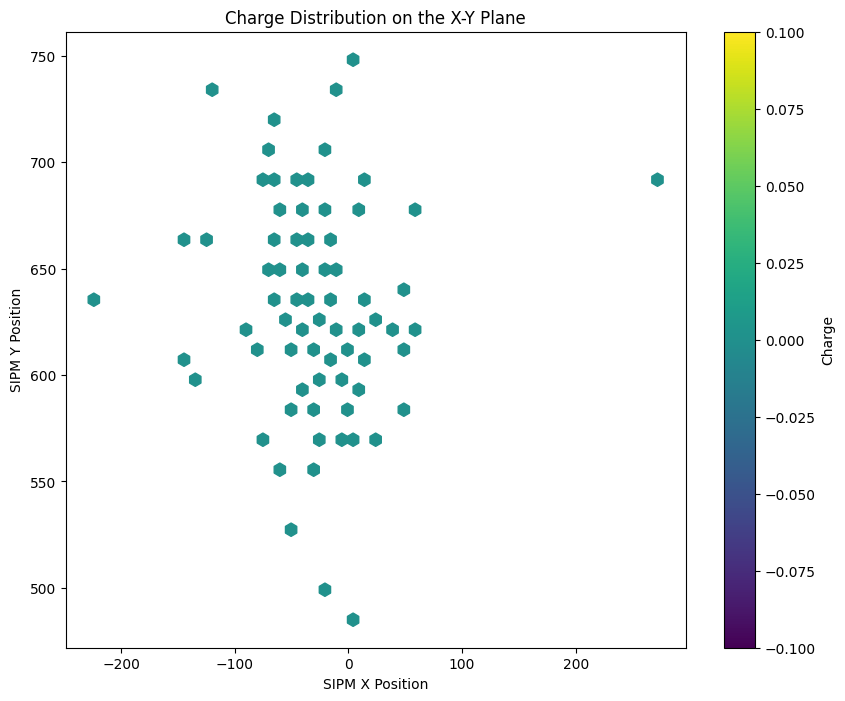

In [33]:
#in DAQ colom 1 is SIPM ID 2 is sipm_x 3 is sipm_y 4 is sipm_z 5 is time 6 is charge 7 is event_no
#make a histogram of charge on the X-Y plane using DAQ_1 data
def plot_charge_histogram(DAQ_data):
    x = [row[1] for row in DAQ_data]  # sipm_x
    y = [row[2] for row in DAQ_data]  # sipm_y
    charge = [row[6] for row in DAQ_data]  # charge
    print(x, y, charge)

    plt.figure(figsize=(10, 8))
    plt.hexbin(x, y, C=charge, gridsize=50, cmap='viridis')
    plt.colorbar(label='Charge')
    plt.xlabel('SIPM X Position')
    plt.ylabel('SIPM Y Position')
    plt.title('Charge Distribution on the X-Y Plane')
    plt.show()
plot_charge_histogram(DAQ_1)

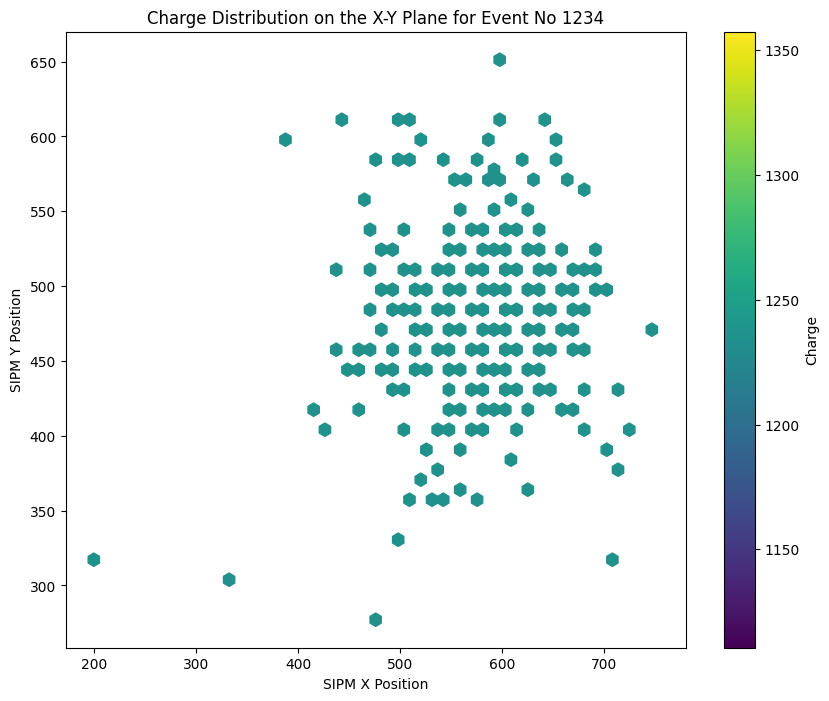

In [ ]:
#I want to do the same thing but for any given event_no
def plot_charge_histogram_for_event(db_file, table_name, event_no):
    DAQ_data = get_all_rows_with_event_no(db_file, table_name, event_no)
    if not DAQ_data:
        print(f"No data found for event_no {event_no}.")
        return
    
    x = [row[1] for row in DAQ_data]  # sipm_x
    y = [row[2] for row in DAQ_data]  # sipm_y
    charge = [row[6] for row in DAQ_data]  # charge

    plt.figure(figsize=(10, 8))
    plt.hexbin(x, y, C=charge, gridsize=50, cmap='viridis',)
    plt.colorbar(label='Charge')
    plt.xlabel('SIPM X Position')
    plt.ylabel('SIPM Y Position')
    plt.title(f'Charge Distribution on the X-Y Plane for Event No {event_no}')
    plt.show()

plot_charge_histogram_for_event(data, 'DAQData', 1234)
#is this charge distribution?


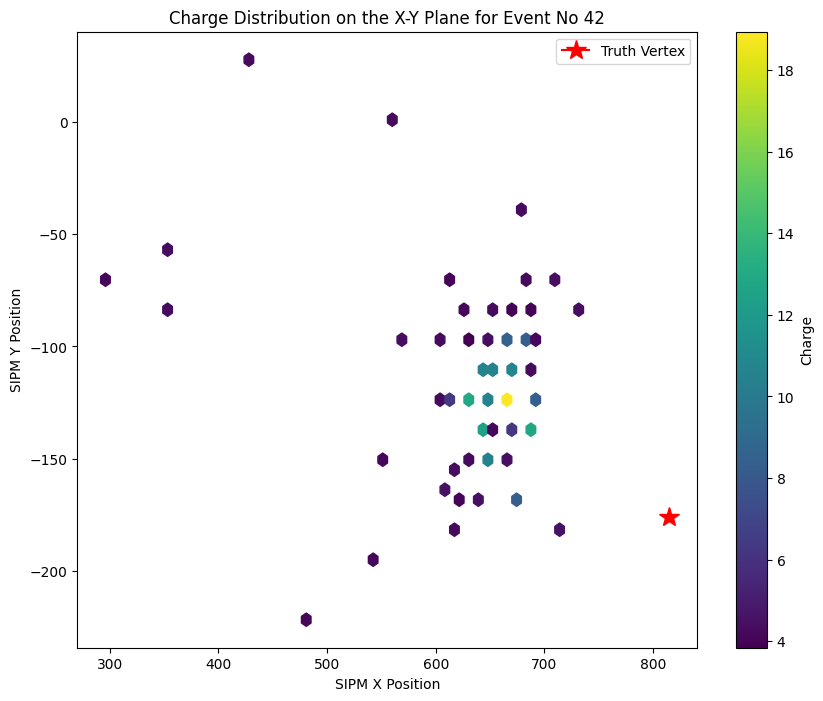

In [50]:
#the coloms in truth go vertex_x, vertexy_y, vertex_z, zenith, azimuth, energy, interaction_time, pid, evnent_no
#use the xyz coordinates of the TruthData with the same event number as the Daq data to plot a star on the histogram
def plot_charge_histogram_with_truth(db_file, daq_table, truth_table, event_no):
    DAQ_data = get_all_rows_with_event_no(db_file, daq_table, event_no)
    Truth_data = get_all_rows_with_event_no(db_file, truth_table, event_no)

    if not DAQ_data or not Truth_data:
        print(f"No data found for event_no {event_no}.")
        return

    x = [row[1] for row in DAQ_data]  # sipm_x
    y = [row[2] for row in DAQ_data]  # sipm_y
    charge = [row[5] for row in DAQ_data]  # charge

    truth_x = Truth_data[0][0]  # vertex_x
    truth_y = Truth_data[0][1]  # vertex_y

    plt.figure(figsize=(10, 8))
    plt.hexbin(x, y, C=charge, gridsize=50, cmap='viridis')
    plt.colorbar(label='Charge')
    plt.xlabel('SIPM X Position')
    plt.ylabel('SIPM Y Position')
    plt.title(f'Charge Distribution on the X-Y Plane for Event No {event_no}')

    # Plot the truth vertex as a star
    plt.plot(truth_x, truth_y, marker='*', markersize=15, color='red', label='Truth Vertex')
    plt.legend()
    
    plt.show()
plot_charge_histogram_with_truth(data, 'DAQData', 'TruthData', 42)


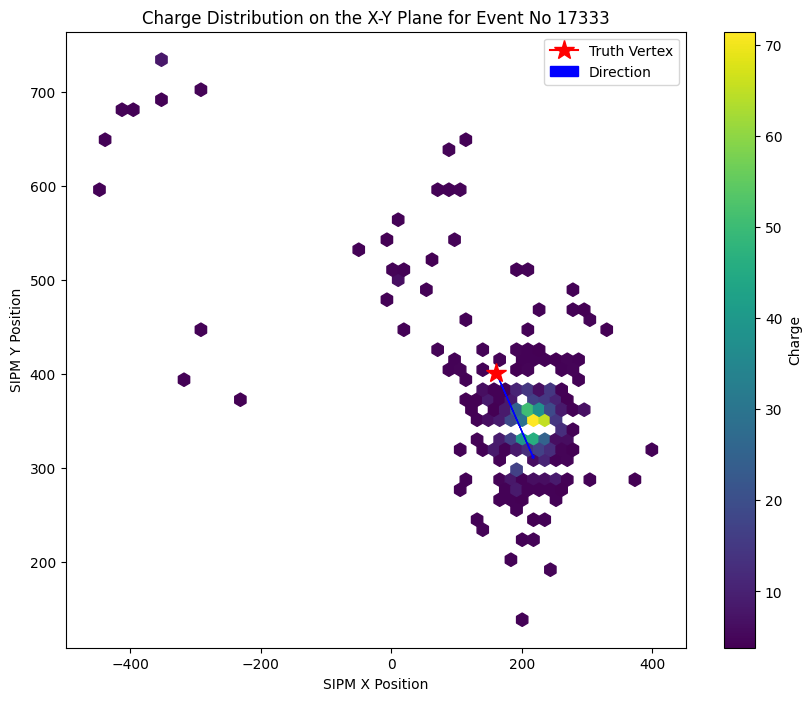

In [71]:
#using the azimuth from the TruthData with the same event number plot a arrow on the histogram representing direction starting at the location of the truth vertex
def plot_charge_histogram_with_direction(db_file, daq_table, truth_table, event_no):
    DAQ_data = get_all_rows_with_event_no(db_file, daq_table, event_no)
    Truth_data = get_all_rows_with_event_no(db_file, truth_table, event_no)

    if not DAQ_data or not Truth_data:
        print(f"No data found for event_no {event_no}.")
        return

    x = [row[1] for row in DAQ_data]  # sipm_x
    y = [row[2] for row in DAQ_data]  # sipm_y
    charge = [row[5] for row in DAQ_data]  # charge

    truth_x = Truth_data[0][0]  # vertex_x
    truth_y = Truth_data[0][1]  # vertex_y
    azimuth = Truth_data[0][4]  # azimuth
    xmin = min(x)
    xmax = max(x)
    ymin = min(y)
    ymax = max(y)
    xscale = xmax - xmin
    yscale = ymax - ymin
    plt.figure(figsize=(10, 8))
    plt.hexbin(x, y, C=charge, gridsize=50, cmap='viridis')
    plt.colorbar(label='Charge')
    plt.xlabel('SIPM X Position')
    plt.ylabel('SIPM Y Position')
    plt.title(f'Charge Distribution on the X-Y Plane for Event No {event_no}')

    # Plot the truth vertex as a star
    plt.plot(truth_x, truth_y, marker='*', markersize=15, color='red', label='Truth Vertex')

    # Calculate the end point of the arrow based on azimuth
    arrow_length = np.sqrt(xscale**2 + yscale**2)/10  # Length of the arrow
    arrow_dx = arrow_length * np.cos(azimuth)
    arrow_dy = arrow_length * np.sin(azimuth)

    plt.arrow(truth_x, truth_y, arrow_dx, arrow_dy, head_width=4.0, head_length=2.5, fc='blue', ec='blue', label='Direction')

    plt.legend()
    
    plt.show()
plot_charge_histogram_with_direction(data, 'DAQData', 'TruthData', 17333)